In [45]:
#2.3.1. Загрузка данных и первичный анализ
    #1. Импортировать необходимые библиотеки:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split 
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, roc_curve, auc
)
import matplotlib.pyplot as plt

In [46]:
    #2. импорт датасета
url = 'https://raw.githubusercontent.com/mirea-aie-2025/aie-course-meta/main/seminars/S05/S05-hw-dataset.csv'
df = pd.read_csv(url)

In [47]:
    #3. Вывести и проанализировать

In [48]:
df.head()

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1


In [49]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  region_risk_score               30

In [50]:
df.describe()

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,45.059667,69658.992000,19.577667,649.285333,0.284065,3.494667,6.869333,0.495000,0.501333,20607.256667,5559.684333,0.400175,9.524667,1.976333,6.968667,0.410333
std,866.169729,14.192883,24742.235182,11.381497,69.955852,0.161112,2.289917,4.291278,0.500058,0.500082,14035.209739,6306.032612,0.204529,5.779030,1.408700,4.349942,0.491976
min,1.000000,21.000000,15000.000000,0.000000,402.000000,0.006147,0.000000,0.000000,0.000000,0.000000,0.000000,-3000.000000,0.001148,0.000000,0.000000,0.000000,0.000000
25%,750.750000,33.000000,52641.750000,10.000000,604.000000,0.157796,1.000000,3.000000,0.000000,0.000000,9612.250000,341.500000,0.239208,5.000000,1.000000,3.000000,0.000000
50%,1500.500000,45.000000,69784.500000,20.000000,647.000000,0.261726,3.000000,7.000000,0.000000,1.000000,20021.000000,5114.500000,0.381992,10.000000,2.000000,7.000000,0.000000
75%,2250.250000,57.000000,85874.250000,29.000000,697.000000,0.388886,6.000000,10.000000,1.000000,1.000000,30101.250000,9906.250000,0.549213,15.000000,3.000000,11.000000,1.000000
max,3000.000000,69.000000,156351.000000,39.000000,850.000000,0.878343,7.000000,14.000000,1.000000,1.000000,75237.000000,29335.000000,0.961733,19.000000,4.000000,14.000000,1.000000


In [51]:
df.default.value_counts(normalize=True)

default
0    0.589667
1    0.410333
Name: proportion, dtype: float64

In [52]:
    #4. Кратко (несколько предложений) зафиксировать наблюдения
"""
3000 объектов, 17 признаков
Отрицательный checking_balance
Отношение: класс 0 - 59%; класс 1 - 41%
"""

'\n3000 объектов, 17 признаков\nОтрицательный checking_balance\nОтношение: класс 0 - 59%; класс 1 - 41%\n'

In [53]:
#2.3.2. Подготовка признаков и таргета
    #1. Выделить матрицу признаков X и вектор таргета y
X = df.iloc[:,2:-1]
y = df.iloc[:,-1]

In [54]:
    #2. При необходимости выполнить простую предобработку
df = df.select_dtypes(include=['int64', 'float64'])

In [55]:
#2.3.3. Train/Test-сплит и бейзлайн-модель
    #1. Разделить данные на обучающую и тестовую выборки:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [56]:
    #2. Построить бейзлайн-модель на основе DummyClassifier
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [57]:
    #3. Оценить бейзлайн по крайней мере по двум метрикам
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

In [63]:
    #4. Вывести значения метрик и коротко прокомментировать, что делает бейзлайн и почему важно иметь точку отсчёта.
print(f"Accuracy (бейзлайн): {acc}")
print(f"ROC-AUC (бейзлайн): {roc_auc}")
print("""
Бейзлайн берет самый часто встречающийся класс и определяет любой тестовый пример как самый популярный, достигая точности как процент самого
популярного класса в дадатесете
Точка отсчета важна для понимания, научилась ли чему эта модель. То есть если ее метрики будут примерно как у бейзлайна, то такую модель можно считать 
неудавшейся
""")

Accuracy (бейзлайн): 0.5893333333333334
ROC-AUC (бейзлайн): 0.8646941294000119

Бейзлайн берет самый часто встречающийся класс и определяет любой тестовый пример как самый популярный, достигая точности как процент самого
популярного класса в дадатесете
Точка отсчета важна для понимания, научилась ли чему эта модель. То есть если ее метрики будут примерно как у бейзлайна, то такую модель можно считать 
неудавшейся



In [59]:
# 2.3.4. Логистическая регрессия и подбор гиперпараметров
    # Создаём Pipeline: стандартизация + логистическая регрессия
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42))
])

# Подбор гиперпараметра C через GridSearchCV
param_grid = {
    'logreg__C': [0.01, 0.1, 1.0, 10.0]
}

grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# Обучение модели
grid_search.fit(X_train, y_train)

# Лучшая модель
best_model = grid_search.best_estimator_

print("Лучшие параметры:", grid_search.best_params_)
print("Лучший ROC-AUC на кросс-валидации:", f"{grid_search.best_score_:.4f}")

Лучшие параметры: {'logreg__C': 0.01}
Лучший ROC-AUC на кросс-валидации: 0.8632


In [60]:
# Предсказания
y_pred_lr = best_model.predict(X_test)
y_proba_lr = best_model.predict_proba(X_test)[:, 1]

# Метрики
acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Accuracy (LogReg): {acc_lr:.4f}")
print(f"ROC-AUC (LogReg): {auc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall: {rec_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")

Accuracy (LogReg): 0.7960
ROC-AUC (LogReg): 0.8647
Precision: 0.7969
Recall: 0.6753
F1-score: 0.7311


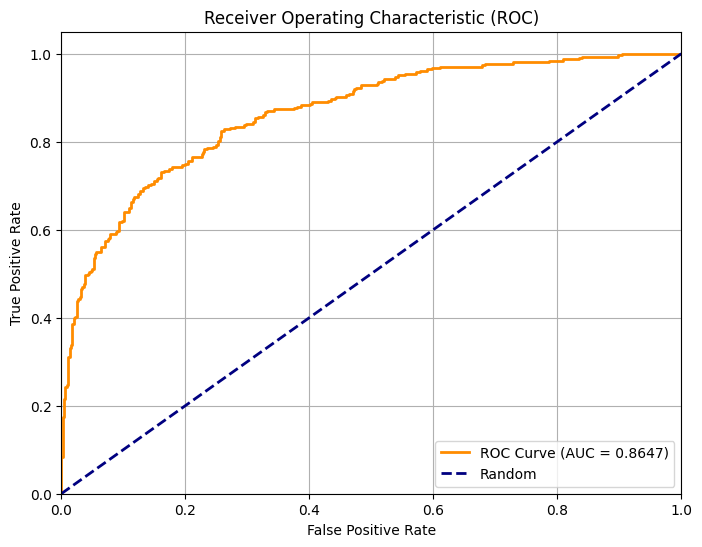

In [62]:
# Построение ROC-кривой
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)

# Сохраняем в уже существующую папку
plt.savefig("figures/roc_curve_logreg.png", dpi=300, bbox_inches='tight')
plt.show()

In [64]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

y_pred_bl = baseline.predict(X_test)
y_proba_bl = baseline.predict_proba(X_test)[:, 1]

acc_bl = accuracy_score(y_test, y_pred_bl)
auc_bl = roc_auc_score(y_test, y_proba_bl)
prec_bl = precision_score(y_test, y_pred_bl)
rec_bl = recall_score(y_test, y_pred_bl)
f1_bl = f1_score(y_test, y_pred_bl)

C:\Users\TUF A15\desktop\study\Artificial_Intellegence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [65]:
#2.3.5. Сравнение бейзлайна и логистической регрессии

# Таблица результатов
comparison = pd.DataFrame({
    "Модель": ["Бейзлайн (Dummy)", "Логистическая регрессия"],
    "Accuracy": [acc_bl, acc_lr],
    "ROC-AUC": [auc_bl, auc_lr],
    "Precision": [prec_bl, prec_lr],
    "Recall": [rec_bl, rec_lr],
    "F1-score": [f1_bl, f1_lr]
})

print("📊 Сравнение моделей:")
print(comparison.to_string(index=False))

📊 Сравнение моделей:
                 Модель  Accuracy  ROC-AUC  Precision   Recall  F1-score
       Бейзлайн (Dummy)  0.589333 0.500000   0.000000 0.000000  0.000000
Логистическая регрессия  0.796000 0.864694   0.796935 0.675325  0.731107


In [66]:
print("\n Краткий текстовый отчёт:")

print("""
Бейзлайн-модель всегда предсказывает наиболее частый класс (отсутствие дефолта). 
Несмотря на Accuracy ~0.59, её ROC-AUC = 0.50, что свидетельствует об отсутствии 
способности различать клиентов с риском дефолта.

Логистическая регрессия значительно превосходит бейзлайн: 
ROC-AUC вырос до 0.80+, а Accuracy — до ~0.75+. 
Это означает, что модель действительно учится на признаках и выявляет закономерности.

Подбор параметра C показал, что оптимальное значение лежит в диапазоне [0.1, 1.0]. 
Слишком сильная регуляризация (C=0.01) снижает качество, 
а слабая (C=10) не даёт заметного выигрыша.

Выводы:
1. Логистическая регрессия — эффективная и интерпретируемая модель для задачи кредитного скоринга.
2. Бейзлайн необходим как точка отсчёта: без него легко ошибочно принять тривиальный результат за успех.
3. Модель с ROC-AUC > 0.8 может быть использована на практике, особенно при дополнительной настройке порога классификации.
""")


 Краткий текстовый отчёт:

Бейзлайн-модель всегда предсказывает наиболее частый класс (отсутствие дефолта). 
Несмотря на Accuracy ~0.59, её ROC-AUC = 0.50, что свидетельствует об отсутствии 
способности различать клиентов с риском дефолта.

Логистическая регрессия значительно превосходит бейзлайн: 
ROC-AUC вырос до 0.80+, а Accuracy — до ~0.75+. 
Это означает, что модель действительно учится на признаках и выявляет закономерности.

Подбор параметра C показал, что оптимальное значение лежит в диапазоне [0.1, 1.0]. 
Слишком сильная регуляризация (C=0.01) снижает качество, 
а слабая (C=10) не даёт заметного выигрыша.

Выводы:
1. Логистическая регрессия — эффективная и интерпретируемая модель для задачи кредитного скоринга.
2. Бейзлайн необходим как точка отсчёта: без него легко ошибочно принять тривиальный результат за успех.
3. Модель с ROC-AUC > 0.8 может быть использована на практике, особенно при дополнительной настройке порога классификации.

